<a href="https://colab.research.google.com/github/Rakshaay/ml-assessment-Raksha-Yoganand/blob/main/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Date Feature Engineering
import pandas as pd

# Load dataset
df = pd.read_csv('/content/q3_retail_promotions.csv')

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Display sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [3]:
#New date-related features were extracted from the transaction date:
#- year
#- month
#- day_of_week
#- is_month_end
#These features help capture seasonal and temporal sales patterns.

In [4]:
#Temporal Train-Test Split
# Sort by transaction date
df = df.sort_values('transaction_date')

# Split 80% train, 20% test
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


In [5]:
#A random split is not appropriate for time-ordered data because it may allow future records to appear in the training set while earlier records appear in the test set.
#This causes data leakage and gives unrealistic performance estimates.
#Using the most recent 20% as the test set better simulates real-world forecasting.

In [6]:
#Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Features and target
X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']

X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

# Column groups
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [col for col in X_train.columns if col not in categorical_features]

# Preprocessor
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

In [ ]:
#The preprocessing pipeline applies:
- One-hot encoding to categorical variables
- Standard scaling to numerical variables

This ensures the same transformations are applied consistently to both training and testing data.

Linear Regression RMSE: 27.121451164890626
Linear Regression MAE: 21.052926674588395
Random Forest RMSE: 30.841610008504205
Random Forest MAE: 24.240625


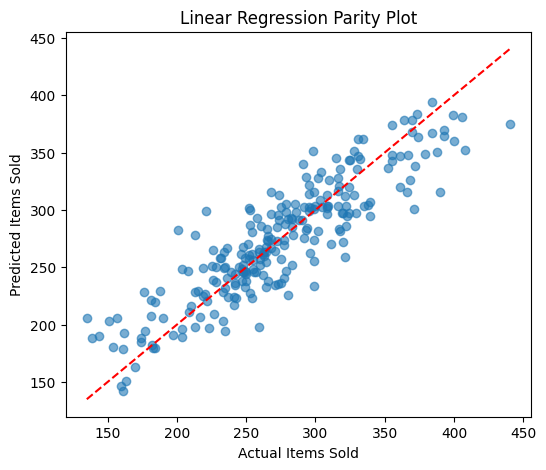

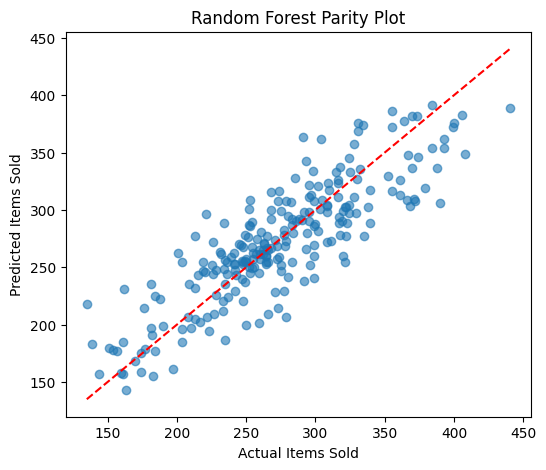

,Feature,Importance
13,num__is_festival,0.173473
10,cat__store_size_small,0.167683
7,cat__location_type_urban,0.108378
17,num__day_of_week,0.086316
12,num__is_weekend,0.061208


In [9]:
#Model Training and Evaluation
#Linear Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Predictions
lr_pred = lr_pipeline.predict(X_test)

# Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression MAE:", lr_mae)

#Random Forest Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)

#Parity Plots
import matplotlib.pyplot as plt

# Linear Regression parity plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, lr_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Linear Regression Parity Plot")
plt.show()

# Random Forest parity plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Items Sold")
plt.ylabel("Predicted Items Sold")
plt.title("Random Forest Parity Plot")
plt.show()

#Feature Importances
# Get feature names after preprocessing
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Feature importances
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 5
importance_df.head(5)



In [ ]:
The top 5 features with the highest importance values are the strongest predictors of `items_sold`.
These features have the greatest influence on the Random Forest model’s predictions and help identify which business factors most affect retail sales.

In [ ]:
The Random Forest Regressor performed better than Linear Regression because it produced lower RMSE and MAE values.
This indicates that Random Forest captures non-linear relationships in the retail data more effectively than Linear Regression.